# 03 — Modelagem LSTM

**Seção 4**:
- **Etapa A**: Baseline LSTM
- **Etapa B**: 4 variações arquiteturais (B1-B4)
- **Etapa C**: Otimização Optuna
- **Etapa D**: Modelo final + Walk-Forward Validation

Observabilidade: MLflow + TensorBoard (Seção 4.4)

In [1]:
import sys, os, logging, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf

sys.path.insert(0, os.path.abspath('..'))
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")

d:\5. Academia\4. Machine Learning Engineering - FIAP\projeto_4\lstm_financial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.21.0


2026-04-20 15:26:49,729 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


GPUs disponíveis: []


In [2]:
# Carregar dados preparados na etapa 02
data = np.load('../data/processed/sequences.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"Input shape: {X_train.shape[1:]}")

Train: X=(2832, 60, 75), y=(2832,)
Val:   X=(560, 60, 75), y=(560,)
Test:  X=(560, 60, 75), y=(560,)
Input shape: (60, 75)


In [3]:
# Setup MLflow
from src.utils.mlflow_utils import setup_mlflow
setup_mlflow(experiment_name='lstm_financial_petr4')

2026-04-20 15:26:54,783 - src.utils.mlflow_utils - INFO - MLflow experiment: 'lstm_financial_petr4' (ID: 1)


'1'

---
## Etapa A — Baseline LSTM

Hiperparâmetros fixos: lr=0.001, batch=64, T=60

In [4]:
from src.model.builder import build_model
from src.model.trainer import train_model
from src.evaluation.metrics import compute_classification_metrics, log_classification_to_mlflow
from src.evaluation.backtester import Backtester

input_shape = X_train.shape[1:]  # (timesteps, features)

# Construir e treinar baseline
model_a = build_model('baseline', input_shape)
model_a.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,737 (612.25 KB)

 Trainable params: 156,353 (610.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
model_a, history_a = train_model(
    model=model_a,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    run_name='etapa_A_baseline',
    learning_rate=0.001,
    batch_size=64,
    epochs=200,
    logs_dir='../logs',
    models_dir='../models',
    tags={'stage': 'A', 'architecture': 'baseline'},
)

2026-04-20 15:26:56,445 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-20 15:26:56,448 - src.model.trainer - INFO - 
2026-04-20 15:26:56,449 - src.model.trainer - INFO - TREINAMENTO: etapa_A_baseline
2026-04-20 15:26:56,450 - src.model.trainer - INFO - ============================================================
2026-04-20 15:26:56,451 - src.model.trainer - INFO -   Arquitetura: baseline_lstm
2026-04-20 15:26:56,451 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-20 15:26:56,452 - src.model.trainer - INFO -   LR: 0.001, Batch: 64, Max epochs: 200
2026-04-20 15:26:56,452 - src.model.trainer - INFO -   Train: 2832, Val: 560
2026-04-20 15:26:56,448 - src.model.trainer - INFO - 
2026-04-20 15:26:56,449 - src.model.trainer - INFO - TREINAMENTO: etapa_A_baseline
2026-04-20 15:26:56,450 - src.model.trainer - INFO - ============================================================
2026-04-20 15:26:56,451 - src.model.trainer - INFO -   

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.5028 - loss: 0.8396 - val_accuracy: 0.4696 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.5028 - loss: 0.8396 - val_accuracy: 0.4696 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5378 - loss: 0.7903 - val_accuracy: 0.4571 - val_loss: 0.7519 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5378 - loss: 0.7903 - val_accuracy: 0.4571 - val_loss: 0.7519 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.5205 - loss: 0.7846 - val_accuracy: 0.4821 - val_loss: 0.7499 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.5205 - loss: 0.7846 - val_accuracy: 0.4821 - val_loss: 0.7499 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.5300 - loss: 0.767

2026/04/20 15:28:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 15:28:31 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/20 15:28:31 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-20 15:29:19,166 - src.model.trainer - INFO -   MLflow run ID: afd3b6abf5234e548830aecc08a36555
2026-04-20 15:29:19,166 - src.model.trainer - INFO -   MLflow run ID: afd3b6abf5234e548830aecc08a36555
2026-04-20 15:29:19,291 - src.model.trainer - INFO - 
  Melhor época: 5
2026-04-20 15:29:19,292 - src.model.trainer - INFO -   Val Loss: 0.7490
2026-04-20 15:29:19,292 - src.model.trainer - INFO -   Val Accuracy: 0.4875
2026-04-20 15:29:19,291 - src.model.trainer - INFO - 
  Melhor época: 5
2026-04-20 15:29:19,292 - src.model.trainer - INFO -   Val Loss: 0.7490
2026-04-20 15:29:19,292 - src.model.trainer - INFO -   Val Accuracy: 0.4875


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


2026-04-20 15:29:20,194 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-20 15:29:20,195 - src.evaluation.metrics - INFO -   accuracy: 0.4875
2026-04-20 15:29:20,195 - src.evaluation.metrics - INFO -   precision: 0.5583
2026-04-20 15:29:20,196 - src.evaluation.metrics - INFO -   recall: 0.4254
2026-04-20 15:29:20,196 - src.evaluation.metrics - INFO -   f1_score: 0.4829
2026-04-20 15:29:20,197 - src.evaluation.metrics - INFO -   auc_roc: 0.4989
2026-04-20 15:29:20,197 - src.evaluation.metrics - INFO -   log_loss: 0.6964
2026-04-20 15:29:20,195 - src.evaluation.metrics - INFO -   accuracy: 0.4875
2026-04-20 15:29:20,195 - src.evaluation.metrics - INFO -   precision: 0.5583
2026-04-20 15:29:20,196 - src.evaluation.metrics - INFO -   recall: 0.4254
2026-04-20 15:29:20,196 - src.evaluation.metrics - INFO -   f1_score: 0.4829
2026-04-20 15:29:20,197 - src.evaluation.metrics - INFO -   auc_roc: 0.4989
2026-04-20 15:29:20,197 - src.evaluation.metrics - INFO -   log_loss: 0.

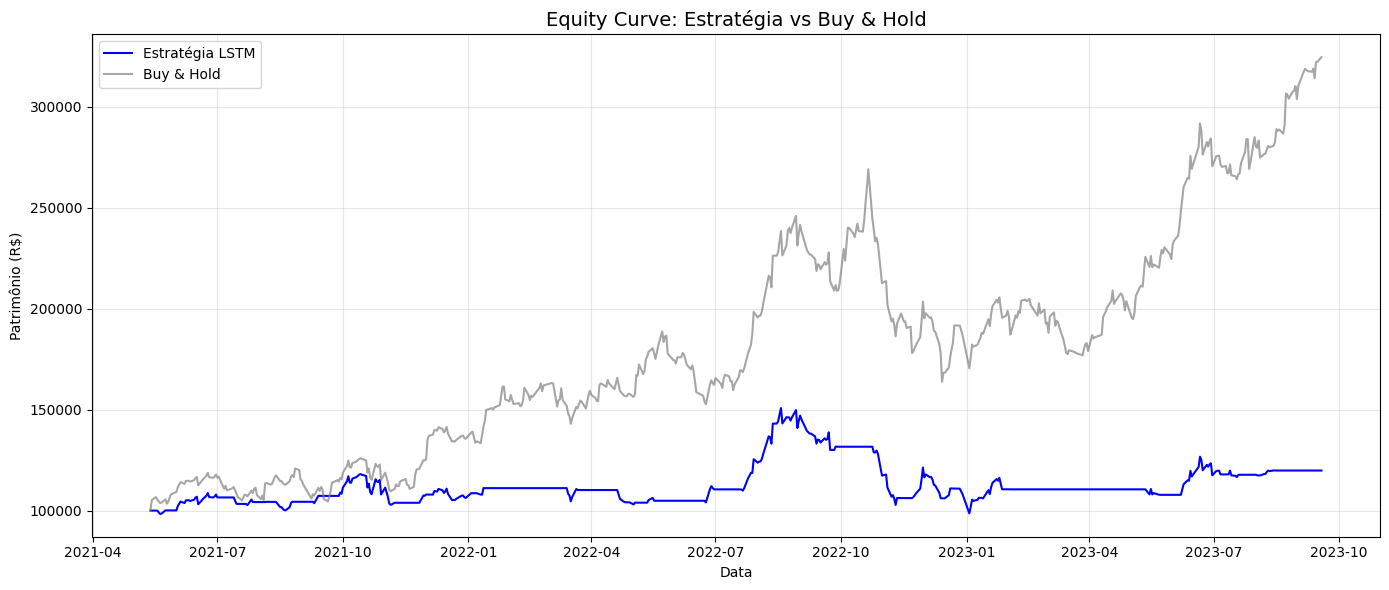

2026-04-20 15:29:22,619 - src.evaluation.backtester - INFO - Drawdown plot salvo: ../reports/etapa_A_baseline/drawdown.png


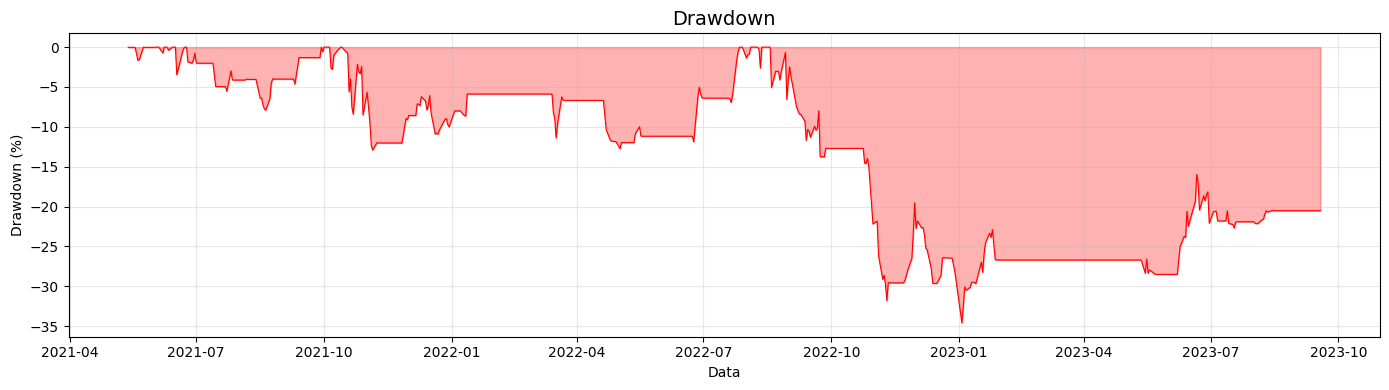

2026-04-20 15:29:22,740 - src.evaluation.backtester - INFO - Relatório salvo: ..\reports\etapa_A_baseline\relatorio_backtest.md


'# Relatório de Backtest\n\n## Métricas Financeiras\n\n| Métrica | Valor |\n|---|---|\n| Retorno Acumulado | 19.81% |\n| Retorno Buy & Hold | 224.43% |\n| CAGR | 8.47% |\n| Sharpe Ratio | -0.0704 |\n| Sortino Ratio | -0.0636 |\n| Max Drawdown | -34.59% |\n| Win Rate | 52.08% |\n| Profit Factor | 1.1285 |\n| Calmar Ratio | 0.2450 |\n| Nº de Trades | 65 |\n| Dias no Período | 560 |\n\n## Configuração\n- Capital Inicial: R$ 100,000.00\n- Custo por Transação: 0.030%\n- Período: 2021-05-13 a 2023-09-18\n'

In [6]:
# Avaliar e backtest na validação
y_pred_a = model_a.predict(X_val).flatten()
metrics_a = compute_classification_metrics(y_val, y_pred_a)

# Calcular retornos reais para backtest
# Carregar features e preços para obter retornos
df_features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
petr4_clean = pd.read_csv('../data/processed/petr4_clean.csv', index_col=0, parse_dates=True)

val_dates = [pd.Timestamp(d) for d in metadata['dates']['val']]
val_returns = petr4_clean.loc[val_dates, 'Close'].pct_change().fillna(0).values
val_prices = petr4_clean.loc[val_dates, 'Close'].values

bt_a = Backtester(
    predictions=(y_pred_a >= 0.5).astype(int),
    actual_returns=val_returns,
    dates=val_dates,
    actual_prices=val_prices,
)
bt_a.run()
bt_metrics_a = bt_a.get_metrics()
fig = bt_a.plot_results(save_path='../reports/etapa_A_baseline/equity_curve.png')
plt.show()
fig = bt_a.plot_drawdown(save_path='../reports/etapa_A_baseline/drawdown.png')
plt.show()
bt_a.generate_report('../reports/etapa_A_baseline')

---
## Etapa B — Teste de Arquiteturas Alternativas

Mesmos hiperparâmetros da Etapa A para comparação justa.

In [7]:
architectures_b = {
    'B1_attention': 'attention',
    'B2_conv1d_lstm': 'conv1d_lstm',
    'B3_bidirectional': 'bidirectional',
    'B4_lstm_gru': 'lstm_gru',
}

results_b = {}

for label, arch_name in architectures_b.items():
    print(f"\n{'='*60}")
    print(f"Treinando {label} ({arch_name})")
    print(f"{'='*60}")
    
    model_b = build_model(arch_name, input_shape)
    model_b, history_b = train_model(
        model=model_b,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        run_name=f'etapa_{label}',
        learning_rate=0.001,
        batch_size=64,
        epochs=200,
        logs_dir='../logs',
        models_dir='../models',
        tags={'stage': 'B', 'architecture': arch_name, 'variant': label},
    )
    
    # Avaliar
    y_pred_b = model_b.predict(X_val).flatten()
    cls_metrics = compute_classification_metrics(y_val, y_pred_b)
    
    # Backtest
    report_dir = f'../reports/etapa_{label}'.replace('B1', 'B1').lower()
    # Mapear nomes de diretório
    dir_map = {
        'B1_attention': 'etapa_B1_attention',
        'B2_conv1d_lstm': 'etapa_B2_conv1d_lstm',
        'B3_bidirectional': 'etapa_B3_bidirectional',
        'B4_lstm_gru': 'etapa_B4_lstm_gru',
    }
    report_dir = f'../reports/{dir_map[label]}'
    
    bt_b = Backtester(
        predictions=(y_pred_b >= 0.5).astype(int),
        actual_returns=val_returns,
        dates=val_dates,
        actual_prices=val_prices,
    )
    bt_b.run()
    bt_met = bt_b.get_metrics()
    bt_b.plot_results(save_path=f'{report_dir}/equity_curve.png')
    bt_b.plot_drawdown(save_path=f'{report_dir}/drawdown.png')
    bt_b.generate_report(report_dir)
    plt.close('all')
    
    results_b[label] = {
        'classification': cls_metrics,
        'backtest': bt_met,
        'model': model_b,
    }
    
    # Limpar sessão
    tf.keras.backend.clear_session()

2026-04-20 15:29:22,841 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-20 15:29:22,843 - src.model.trainer - INFO - 
2026-04-20 15:29:22,843 - src.model.trainer - INFO - TREINAMENTO: etapa_B1_attention
2026-04-20 15:29:22,844 - src.model.trainer - INFO - ============================================================
2026-04-20 15:29:22,844 - src.model.trainer - INFO -   Arquitetura: attention_lstm
2026-04-20 15:29:22,844 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-20 15:29:22,845 - src.model.trainer - INFO -   LR: 0.001, Batch: 64, Max epochs: 200
2026-04-20 15:29:22,845 - src.model.trainer - INFO -   Train: 2832, Val: 560
2026-04-20 15:29:22,843 - src.model.trainer - INFO - 
2026-04-20 15:29:22,843 - src.model.trainer - INFO - TREINAMENTO: etapa_B1_attention
2026-04-20 15:29:22,844 - src.model.trainer - INFO - ============================================================
2026-04-20 15:29:22,844 - src.model.trainer - INFO


Treinando B1_attention (attention)
Epoch 1/200
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.5049 - loss: 0.7778 - val_accuracy: 0.5143 - val_loss: 0.7552 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.5049 - loss: 0.7778 - val_accuracy: 0.5143 - val_loss: 0.7552 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.4996 - loss: 0.7585 - val_accuracy: 0.4679 - val_loss: 0.7614 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.4996 - loss: 0.7585 - val_accuracy: 0.4679 - val_loss: 0.7614 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.5148 - loss: 0.7495 - val_accuracy: 0.4625 - val_loss: 0.7708 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.5148 - loss: 0.7495 - val_accuracy: 0.4625 - val_loss: 0.7708 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━

2026/04/20 15:31:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 15:31:10 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/20 15:31:10 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-20 15:31:22,548 - src.model.trainer - INFO -   MLflow run ID: 2b86b0c27b124e66aa9c5a1a2e1e7dff
2026-04-20 15:31:22,548 - src.model.trainer - INFO -   MLflow run ID: 2b86b0c27b124e66aa9c5a1a2e1e7dff
2026-04-20 15:31:22,680 - src.model.trainer - INFO - 
  Melhor época: 9
2026-04-20 15:31:22,681 - src.model.trainer - INFO -   Val Loss: 0.7348
2026-04-20 15:31:22,681 - src.model.trainer - INFO -   Val Accuracy: 0.4946
2026-04-20 15:31:22,680 - src.model.trainer - INFO - 
  Melhor época: 9
2026-04-20 15:31:22,681 - src.model.trainer - INFO -   Val Loss: 0.7348
2026-04-20 15:31:22,681 - src.model.trainer - INFO -   Val Accuracy: 0.4946


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


2026-04-20 15:31:23,617 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-20 15:31:23,618 - src.evaluation.metrics - INFO -   accuracy: 0.4946
2026-04-20 15:31:23,618 - src.evaluation.metrics - INFO -   precision: 0.5860
2026-04-20 15:31:23,619 - src.evaluation.metrics - INFO -   recall: 0.3460
2026-04-20 15:31:23,619 - src.evaluation.metrics - INFO -   f1_score: 0.4351
2026-04-20 15:31:23,619 - src.evaluation.metrics - INFO -   auc_roc: 0.5338
2026-04-20 15:31:23,620 - src.evaluation.metrics - INFO -   log_loss: 0.6959
2026-04-20 15:31:23,622 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-20 15:31:23,624 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-20 15:31:23,624 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 85.77
2026-04-20 15:31:23,625 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-20 15:31:23,625 - src.evaluation.backtester - INFO -   cagr_pct: 32.14
2026-04-20 15:31:23,62

...

2026-04-20 15:34:17,043 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-20 15:34:17,044 - src.evaluation.metrics - INFO -   accuracy: 0.5089
2026-04-20 15:34:17,044 - src.evaluation.metrics - INFO -   precision: 0.5787
2026-04-20 15:34:17,045 - src.evaluation.metrics - INFO -   recall: 0.4667
2026-04-20 15:34:17,045 - src.evaluation.metrics - INFO -   f1_score: 0.5167
2026-04-20 15:34:17,046 - src.evaluation.metrics - INFO -   auc_roc: 0.5231
2026-04-20 15:34:17,047 - src.evaluation.metrics - INFO -   log_loss: 0.6961
2026-04-20 15:34:17,049 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-20 15:34:17,051 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-20 15:34:17,052 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 80.38
2026-04-20 15:34:17,052 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-20 15:34:17,052 - src.evaluation.backtester - INFO -   cagr_pct: 30.4
2026-04-20 15:34:17,053


Treinando B4_lstm_gru (lstm_gru)
Epoch 1/200
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.4979 - loss: 0.9077 - val_accuracy: 0.5214 - val_loss: 0.7491 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.4979 - loss: 0.9077 - val_accuracy: 0.5214 - val_loss: 0.7491 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5152 - loss: 0.8139 - val_accuracy: 0.5411 - val_loss: 0.7429 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5152 - loss: 0.8139 - val_accuracy: 0.5411 - val_loss: 0.7429 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5268 - loss: 0.7961 - val_accuracy: 0.5054 - val_loss: 0.7473 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5268 - loss: 0.7961 - val_accuracy: 0.5054 - val_loss: 0.7473 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 

2026/04/20 15:35:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 15:35:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/20 15:35:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-20 15:35:27,363 - src.model.trainer - INFO -   MLflow run ID: b081e8f2fdf2423a92a554a4345aea1b
2026-04-20 15:35:27,363 - src.model.trainer - INFO -   MLflow run ID: b081e8f2fdf2423a92a554a4345aea1b
2026-04-20 15:35:27,475 - src.model.trainer - INFO - 
  Melhor época: 1
2026-04-20 15:35:27,476 - src.model.trainer - INFO -   Val Loss: 0.7429
2026-04-20 15:35:27,477 - src.model.trainer - INFO -   Val Accuracy: 0.5411
2026-04-20 15:35:27,475 - src.model.trainer - INFO - 
  Melhor época: 1
2026-04-20 15:35:27,476 - src.model.trainer - INFO -   Val Loss: 0.7429
2026-04-20 15:35:27,477 - src.model.trainer - INFO -   Val Accuracy: 0.5411


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


2026-04-20 15:35:28,329 - src.evaluation.metrics - INFO - Métricas de classificação:
2026-04-20 15:35:28,330 - src.evaluation.metrics - INFO -   accuracy: 0.5411
2026-04-20 15:35:28,330 - src.evaluation.metrics - INFO -   precision: 0.5694
2026-04-20 15:35:28,330 - src.evaluation.metrics - INFO -   recall: 0.7556
2026-04-20 15:35:28,331 - src.evaluation.metrics - INFO -   f1_score: 0.6494
2026-04-20 15:35:28,331 - src.evaluation.metrics - INFO -   auc_roc: 0.5016
2026-04-20 15:35:28,331 - src.evaluation.metrics - INFO -   log_loss: 0.6916
2026-04-20 15:35:28,333 - src.evaluation.backtester - INFO - Backtest executado com sucesso.
2026-04-20 15:35:28,335 - src.evaluation.backtester - INFO - Métricas financeiras:
2026-04-20 15:35:28,337 - src.evaluation.backtester - INFO -   retorno_acumulado_pct: 142.27
2026-04-20 15:35:28,337 - src.evaluation.backtester - INFO -   retorno_bh_pct: 224.43
2026-04-20 15:35:28,338 - src.evaluation.backtester - INFO -   cagr_pct: 48.91
2026-04-20 15:35:28,3

In [8]:
# Tabela comparativa Etapas A + B
comparison = []

# Etapa A
comparison.append({
    'Modelo': 'A - Baseline',
    'AUC-ROC': metrics_a['auc_roc'],
    'F1': metrics_a['f1_score'],
    'Accuracy': metrics_a['accuracy'],
    'Sharpe': bt_metrics_a['sharpe_ratio'],
    'Sortino': bt_metrics_a['sortino_ratio'],
    'MaxDD%': bt_metrics_a['max_drawdown_pct'],
    'WinRate%': bt_metrics_a['win_rate_pct'],
    'RetAcum%': bt_metrics_a['retorno_acumulado_pct'],
})

# Etapas B
for label, res in results_b.items():
    comparison.append({
        'Modelo': label,
        'AUC-ROC': res['classification']['auc_roc'],
        'F1': res['classification']['f1_score'],
        'Accuracy': res['classification']['accuracy'],
        'Sharpe': res['backtest']['sharpe_ratio'],
        'Sortino': res['backtest']['sortino_ratio'],
        'MaxDD%': res['backtest']['max_drawdown_pct'],
        'WinRate%': res['backtest']['win_rate_pct'],
        'RetAcum%': res['backtest']['retorno_acumulado_pct'],
    })

df_comparison = pd.DataFrame(comparison)
display(df_comparison.sort_values('AUC-ROC', ascending=False))

# Salvar
df_comparison.to_csv('../reports/tabela_comparativa_AB.csv', index=False)

# Determinar melhor arquitetura
best_row = df_comparison.sort_values('AUC-ROC', ascending=False).iloc[0]
print(f"\n🏆 Melhor modelo: {best_row['Modelo']} (AUC-ROC={best_row['AUC-ROC']:.4f}, Sharpe={best_row['Sharpe']:.4f})")

,Modelo,AUC-ROC,F1,Accuracy,Sharpe,Sortino,MaxDD%,WinRate%,RetAcum%
1,B1_attention,0.533826,0.435130,0.494643,0.7878,0.6260,-23.06,56.99,85.77
3,B3_bidirectional,0.523084,0.516696,0.508929,0.6645,0.6281,-32.66,57.09,80.38
4,B4_lstm_gru,0.501613,0.649386,0.541071,0.9915,1.2053,-23.47,55.98,142.27
0,A - Baseline,0.498866,0.482883,0.487500,-0.0704,-0.0636,-34.59,52.08,19.81
2,B2_conv1d_lstm,0.494500,0.451243,0.487500,-0.0902,-0.0729,-21.25,56.73,20.06



🏆 Melhor modelo: B1_attention (AUC-ROC=0.5338, Sharpe=0.7878)


---
## Etapa C — Otimização de Hiperparâmetros (Optuna)

Usar a arquitetura vencedora da etapa anterior.

In [9]:
from src.model.tuner import run_optuna_optimization

# Definir a melhor arquitetura manualmente após análise da tabela acima
# (ajustar conforme resultado real)
BEST_ARCHITECTURE = 'baseline'  # ← AJUSTAR após análise das etapas A/B

print(f"Arquitetura selecionada para otimização: {BEST_ARCHITECTURE}")
print(f"Iniciando Optuna com 50 trials...")

study, best_params = run_optuna_optimization(
    architecture=BEST_ARCHITECTURE,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    n_trials=50,
)

print(f"\nMelhores hiperparâmetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC: {study.best_value:.4f}")

2026-04-20 15:35:29,932 - src.model.tuner - INFO - ============================================================
2026-04-20 15:35:29,933 - src.model.tuner - INFO - OTIMIZAÇÃO DE HIPERPARÂMETROS (Etapa C)
2026-04-20 15:35:29,933 - src.model.tuner - INFO - Arquitetura: baseline, Trials: 50
2026-04-20 15:35:29,933 - src.model.tuner - INFO - ============================================================
2026-04-20 15:35:29,933 - src.model.tuner - INFO - OTIMIZAÇÃO DE HIPERPARÂMETROS (Etapa C)
2026-04-20 15:35:29,933 - src.model.tuner - INFO - Arquitetura: baseline, Trials: 50
2026-04-20 15:35:29,933 - src.model.tuner - INFO - ============================================================


Arquitetura selecionada para otimização: baseline
Iniciando Optuna com 50 trials...


[I 2026-04-20 15:35:30,457] A new study created in memory with name: lstm_baseline_optimization
Best trial: 0. Best value: 0.528409:   2%|▏         | 1/50 [00:32<26:22, 32.29s/it]

[I 2026-04-20 15:36:02,748] Trial 0 finished with value: 0.5284094590217039 and parameters: {'window_size': 45, 'lstm1_units': 64, 'lstm2_units': 128, 'dense_units': 32, 'dropout_lstm': 0.35530372183919845, 'dropout_dense': 0.10295859844911176, 'learning_rate': 0.0016795554432344462, 'batch_size': 32, 'use_batchnorm': True, 'l2_reg': 6.881387070416553e-05}. Best is trial 0 with value: 0.5284094590217039.


2026-04-20 15:36:32,090 - src.model.tuner - INFO -   Trial 1: AUC-ROC=0.5062
Best trial: 0. Best value: 0.528409:   4%|▍         | 2/50 [01:01<24:26, 30.56s/it]

...

[I 2026-04-20 16:48:17,244] Trial 48 finished with value: 0.4862714609653385 and parameters: {'window_size': 45, 'lstm1_units': 256, 'lstm2_units': 128, 'dense_units': 32, 'dropout_lstm': 0.23505978816133716, 'dropout_dense': 0.3808824242344097, 'learning_rate': 0.00081780204502476, 'batch_size': 128, 'use_batchnorm': False, 'l2_reg': 2.4001944539256883e-05}. Best is trial 24 with value: 0.546550048590865.


2026-04-20 16:48:44,472 - src.model.tuner - INFO -   Trial 49: AUC-ROC=0.5114
Best trial: 24. Best value: 0.54655: 100%|██████████| 50/50 [1:13:14<00:00, 87.88s/it]



[I 2026-04-20 16:48:44,473] Trial 49 finished with value: 0.5114220926465824 and parameters: {'window_size': 30, 'lstm1_units': 64, 'lstm2_units': 128, 'dense_units': 48, 'dropout_lstm': 0.36377101652849136, 'dropout_dense': 0.19500368388756767, 'learning_rate': 0.0011548838202080716, 'batch_size': 64, 'use_batchnorm': True, 'l2_reg': 3.272319772765729e-05}. Best is trial 24 with value: 0.546550048590865.


2026-04-20 16:48:44,711 - src.model.tuner - INFO - 
Melhor AUC-ROC: 0.5466
2026-04-20 16:48:44,712 - src.model.tuner - INFO - Melhores parâmetros: {'window_size': 90, 'lstm1_units': 256, 'lstm2_units': 96, 'dense_units': 32, 'dropout_lstm': 0.19383446219903455, 'dropout_dense': 0.3465395223895521, 'learning_rate': 0.001716330657168487, 'batch_size': 128, 'use_batchnorm': True, 'l2_reg': 2.496838642760779e-05}
2026-04-20 16:48:44,712 - src.model.tuner - INFO - Melhores parâmetros: {'window_size': 90, 'lstm1_units': 256, 'lstm2_units': 96, 'dense_units': 32, 'dropout_lstm': 0.19383446219903455, 'dropout_dense': 0.3465395223895521, 'learning_rate': 0.001716330657168487, 'batch_size': 128, 'use_batchnorm': True, 'l2_reg': 2.496838642760779e-05}



Melhores hiperparâmetros:
  window_size: 90
  lstm1_units: 256
  lstm2_units: 96
  dense_units: 32
  dropout_lstm: 0.19383446219903455
  dropout_dense: 0.3465395223895521
  learning_rate: 0.001716330657168487
  batch_size: 128
  use_batchnorm: True
  l2_reg: 2.496838642760779e-05

Melhor AUC-ROC: 0.5466


In [10]:
# Visualização Optuna
import optuna.visualization as vis

fig = vis.plot_optimization_history(study)
fig.show()

fig = vis.plot_param_importances(study)
fig.show()

---
## Etapa D — Modelo Final + Walk-Forward Validation

In [15]:
from src.model.builder import build_model
from src.model.trainer import train_model
from src.utils.serialization import save_model, save_metrics

# Construir modelo final com melhores hiperparâmetros
best_window = best_params.get('window_size', 60)

# Ajustar dados se window_size diferente
if best_window <= X_train.shape[1]:
    X_train_final = X_train[:, -best_window:, :]
    X_val_final = X_val[:, -best_window:, :]
    X_test_final = X_test[:, -best_window:, :]
else:
    X_train_final, X_val_final, X_test_final = X_train, X_val, X_test

input_shape_final = X_train_final.shape[1:]

build_kwargs = {
    'dense_units': best_params.get('dense_units', 32),
    'dropout_lstm': best_params.get('dropout_lstm', 0.3),
    'dropout_dense': best_params.get('dropout_dense', 0.2),
    'use_batchnorm': best_params.get('use_batchnorm', True),
}
if BEST_ARCHITECTURE in ('baseline', 'attention', 'conv1d_lstm', 'bidirectional'):
    build_kwargs['lstm1_units'] = best_params.get('lstm1_units', 128)
    build_kwargs['lstm2_units'] = best_params.get('lstm2_units', 64)
elif BEST_ARCHITECTURE == 'lstm_gru':
    build_kwargs['lstm_units'] = best_params.get('lstm1_units', 128)
    build_kwargs['gru_units'] = best_params.get('lstm2_units', 64)

model_final = build_model(BEST_ARCHITECTURE, input_shape_final, **build_kwargs)
model_final.summary()

Model: "baseline_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 256)        │       339,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 96)             │       135,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 96)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,065 (1.83 MB)

 Trainable params: 479,361 (1.83 MB)

 Non-trainable params: 704 (2.75 KB)

In [16]:
model_final, history_final = train_model(
    model=model_final,
    X_train=X_train_final, y_train=y_train,
    X_val=X_val_final, y_val=y_val,
    run_name='etapa_D_modelo_final',
    learning_rate=best_params.get('learning_rate', 0.001),
    batch_size=best_params.get('batch_size', 64),
    epochs=200,
    logs_dir='../logs',
    models_dir='../models',
    tags={'stage': 'D', 'architecture': BEST_ARCHITECTURE, 'status': 'final'},
)

2026-04-20 17:29:20,486 - src.model.trainer - INFO - Class weights: {0: 1.032069970845481, 1: 0.9698630136986301}
2026-04-20 17:29:20,487 - src.model.trainer - INFO - 
2026-04-20 17:29:20,487 - src.model.trainer - INFO - TREINAMENTO: etapa_D_modelo_final
2026-04-20 17:29:20,488 - src.model.trainer - INFO - ============================================================
2026-04-20 17:29:20,488 - src.model.trainer - INFO -   Arquitetura: baseline_lstm
2026-04-20 17:29:20,488 - src.model.trainer - INFO -   Input shape: (60, 75)
2026-04-20 17:29:20,489 - src.model.trainer - INFO -   LR: 0.001716330657168487, Batch: 128, Max epochs: 200
2026-04-20 17:29:20,489 - src.model.trainer - INFO -   Train: 2832, Val: 560
2026-04-20 17:29:20,487 - src.model.trainer - INFO - 
2026-04-20 17:29:20,487 - src.model.trainer - INFO - TREINAMENTO: etapa_D_modelo_final
2026-04-20 17:29:20,488 - src.model.trainer - INFO - ============================================================
2026-04-20 17:29:20,488 - src.m

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.4940 - loss: 0.9448 - val_accuracy: 0.4429 - val_loss: 0.8142 - learning_rate: 0.0017
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step - accuracy: 0.4940 - loss: 0.9448 - val_accuracy: 0.4429 - val_loss: 0.8142 - learning_rate: 0.0017
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.5230 - loss: 0.8642 - val_accuracy: 0.4768 - val_loss: 0.7972 - learning_rate: 0.0017
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.5230 - loss: 0.8642 - val_accuracy: 0.4768 - val_loss: 0.7972 - learning_rate: 0.0017
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.5244 - loss: 0.8290 - val_accuracy: 0.4482 - val_loss: 0.8071 - learning_rate: 0.0017
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.5244 - loss: 0.8290 - val_accuracy: 0.4482 - val_loss: 0.8071 - learning_rate: 0.0017
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.5081 - loss: 0.

2026/04/20 17:31:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 17:31:15 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/04/20 17:31:15 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-04-20 17:31:23,556 - src.model.trainer - INFO -   MLflow run ID: 7775212f6af84b8db737fa21b729d8a6
2026-04-20 17:31:23,556 - src.model.trainer - INFO -   MLflow run ID: 7775212f6af84b8db737fa21b729d8a6
2026-04-20 17:31:23,669 - src.model.trainer - INFO - 
  Melhor época: 4
2026-04-20 17:31:23,670 - src.model.trainer - INFO -   Val Loss: 0.7799
2026-04-20 17:31:23,670 - src.model.trainer - INFO -   Val Accuracy: 0.5482
2026-04-20 17:31:23,669 - src.model.trainer - INFO - 
  Melhor época: 4
2026-04-20 17:31:23,670 - src.model.trainer - INFO -   Val Loss: 0.7799
2026-04-20 17:31:23,670 - src.model.trainer - INFO -   Val Accuracy: 0.5482


In [17]:
# Salvar modelo final
save_model(model_final, '../models/model.keras')
save_metrics(test_cls_metrics, '../models/metrics.json')

print("\n✅ Etapa D concluída — modelo final salvo.")
print("Próximo passo: Etapa E (Backtest Final) no notebook 04.")

2026-04-20 17:31:23,725 - src.utils.serialization - INFO - Modelo salvo: ../models/model.keras
2026-04-20 17:31:23,726 - src.utils.serialization - INFO - Métricas salvas: ../models/metrics.json
2026-04-20 17:31:23,726 - src.utils.serialization - INFO - Métricas salvas: ../models/metrics.json



✅ Etapa D concluída — modelo final salvo.
Próximo passo: Etapa E (Backtest Final) no notebook 04.
